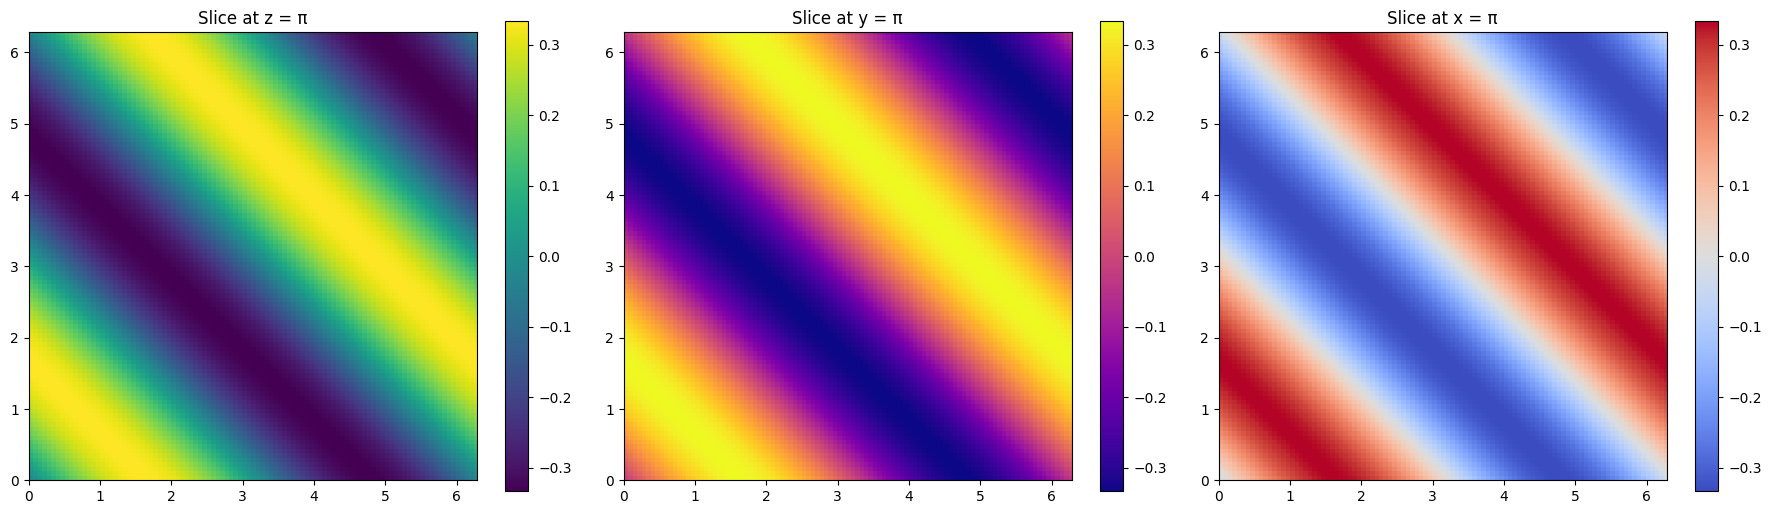

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fftn, ifftn, fftfreq

# Step 1: Collocation Points
N = 101
L = 2 * np.pi
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
z = np.linspace(0, L, N, endpoint=False)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Step 2: RHS f(x, y, z)
f = np.sin(X + Y + Z)

# Step 3: Forward 3D FFT
f_hat = fftn(f)

# Step 4: Wavenumber Arrays
k = fftfreq(N, d=(L/N)) * 2 * np.pi
kx, ky, kz = np.meshgrid(k, k, k, indexing='ij')

# Step 5: Solve in Fourier Space
k2 = kx**2 + ky**2 + kz**2
k2[0, 0, 0] = 1            # avoid division by zero
V_hat = -f_hat / k2
V_hat[0, 0, 0] = 0         # set mean to zero

# Step 6: Inverse FFT
V = np.real(ifftn(V_hat))

# Step 7: Plot 2D slices
slice_index = N // 2

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(V[:, :, slice_index], extent=[0, L, 0, L], origin='lower', cmap='viridis')
plt.title('Slice at z = π')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(V[:, slice_index, :], extent=[0, L, 0, L], origin='lower', cmap='plasma')
plt.title('Slice at y = π')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(V[slice_index, :, :], extent=[0, L, 0, L], origin='lower', cmap='coolwarm')
plt.title('Slice at x = π')
plt.colorbar()

plt.tight_layout()
plt.show()
